# PV Tilt

Compare eddy tilt direction with planetary, topographic, and total shallow-water PV-gradient directions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

df_eddies[["Eddy", "Day", "Cyc", "Region", "TiltDis", "TiltDir", "PV_grad_mag", "dtheta_PV_grad"]].head()


,Eddy,Day,Cyc,Region,TiltDis,TiltDir,PV_grad_mag,dtheta_PV_grad
0,1,1462,CE,U2,NaN,NaN,NaN,NaN
1,1,1463,CE,U2,NaN,NaN,NaN,NaN
2,1,1464,CE,U2,NaN,NaN,NaN,NaN
3,1,1465,CE,U2,33.976810,184.917206,1.687799e-13,61.808257
4,1,1466,CE,U2,30.067059,181.174121,1.775356e-13,57.411306


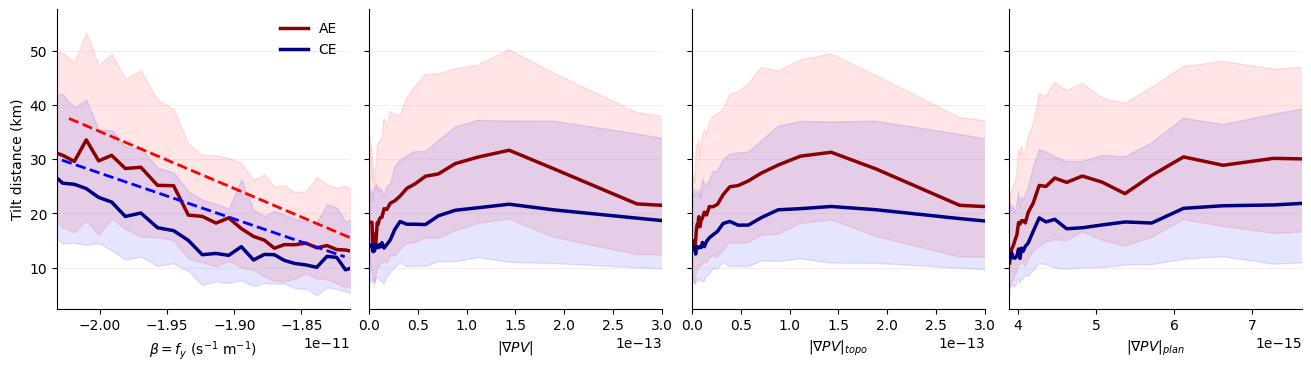

In [2]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True, constrained_layout=True)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("PV_grad_mag", r"$|\nabla PV|$", (0, 3e-13), False),
    ("PV_grad_topo_mag", r"$|\nabla PV|_{topo}$", (0, 3e-13), False),
    ("PV_grad_plan_mag", r"$|\nabla PV|_{plan}$", None, False),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()


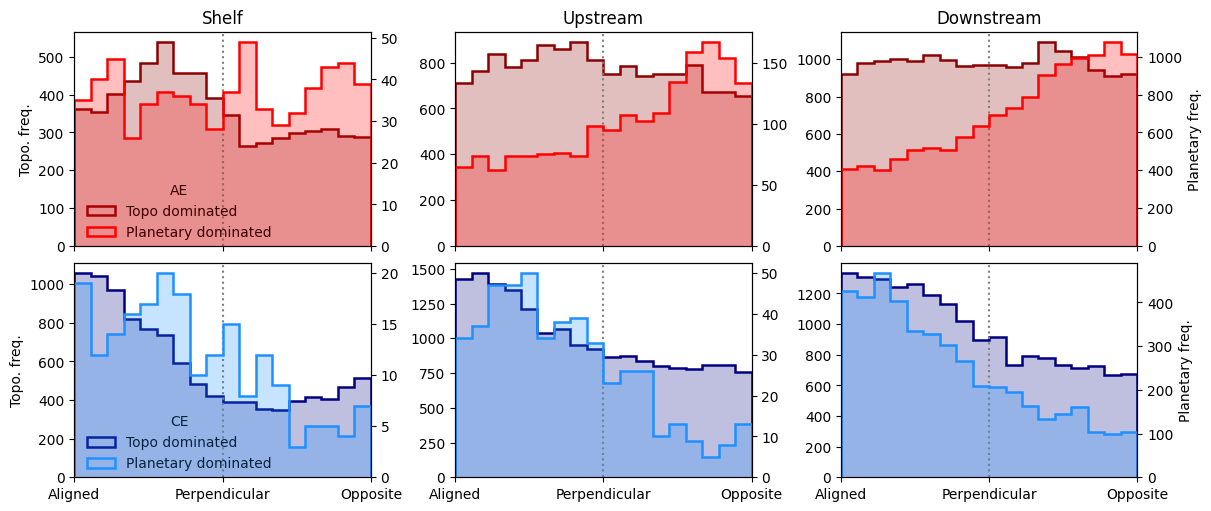

In [49]:
bins = np.arange(0, 181, 10)

region_groups = {
    "Shelf": ["S1", "S2"],
    "Upstream": ["U1", "U2"],
    "Downstream": ["D1", "D2"],
}

fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 5),
    sharex=True,
    constrained_layout=True
)

colors = {
    "AE": ("darkred", "red"),
    "CE": ("navy", "dodgerblue"),
}

theta_col = "dtheta_PV_grad"

for r, cyc in enumerate(["AE", "CE"]):

    color_topo, color_plan = colors[cyc]

    for c, (title, regs) in enumerate(region_groups.items()):

        ax = axs[r, c]
        ax2 = ax.twinx()

        # Topography dominated (left axis)
        vals = df_eddies.loc[
            (df_eddies.Cyc == cyc)
            & (df_eddies.Region.isin(regs))
            & (df_eddies.topo_plan_ratio > 0),
            theta_col
        ].dropna()

        ax.hist(vals, bins=bins, histtype="stepfilled",
                alpha=0.25, color=color_topo)
        ax.hist(vals, bins=bins, histtype="step",
                lw=1.8, color=color_topo, label="Topo dominated")

        # Planetary dominated (right axis)
        vals = df_eddies.loc[
            (df_eddies.Cyc == cyc)
            & (df_eddies.Region.isin(regs))
            & (df_eddies.topo_plan_ratio < 0),
            theta_col
        ].dropna()

        ax2.hist(vals, bins=bins, histtype="stepfilled",
                 alpha=0.25, color=color_plan)
        ax2.hist(vals, bins=bins, histtype="step",
                 lw=1.8, color=color_plan, label="Planetary dominated")

        ax.axvline(90, color="0.5", ls=":")
        ax.set_xlim(0, 180)

        if r == 0:
            ax.set_title(title)

        if c == 0:
            # ax.set_ylabel(f"{cyc}\nTopo dominated")
            # ax2.set_ylabel("Planetary dominated")

            # ax.set_ylabel(f"{cyc}\nTopo freq.")
            ax.set_ylabel(f"Topo. freq.")
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            # ax.legend(h1 + h2, l1 + l2, title=cyc, frameon=False)
            ax.legend(
                h1 + h2,
                l1 + l2,
                title=cyc,
                frameon=False,
                loc="upper left",
                bbox_to_anchor=(0, .35)
            )
            
        if c == 2:
            ax2.set_ylabel("Planetary freq.")

        if r == 1:
            ax.set_xticks([0, 90, 180])
            ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])

plt.show()


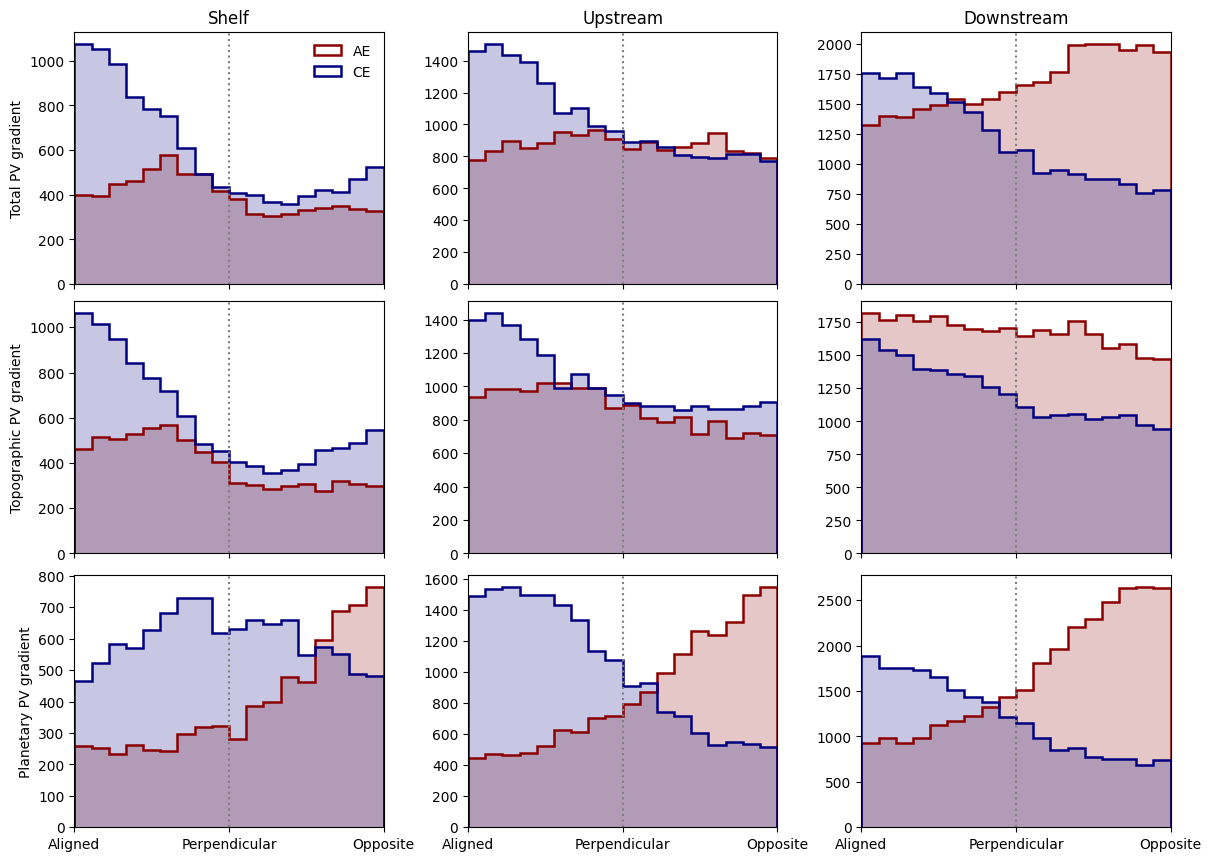

In [3]:
theta_cols = ["dtheta_PV_grad", "dtheta_PV_grad_topo", "dtheta_PV_grad_plan"]
row_labels = ["Total PV gradient", "Topographic PV gradient", "Planetary PV gradient"]
region_groups = [["S1", "S2"], ["U1", "U2"], ["D1", "D2"]]
region_titles = ["Shelf", "Upstream", "Downstream"]
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(3, 3, figsize=(12, 8.5), sharex=True, constrained_layout=True)
for r, (theta_col, row_label) in enumerate(zip(theta_cols, row_labels)):
    for c, regs in enumerate(region_groups):
        ax = axs[r, c]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            vals = df_eddies.loc[(df_eddies.Cyc == cyc) & (df_eddies.Region.isin(regs)), theta_col].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if (r, c) == (0, 0) else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        if r == 0:
            ax.set_title(region_titles[c])
        if c == 0:
            ax.set_ylabel(row_label)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0, 0].legend(frameon=False)
plt.show()


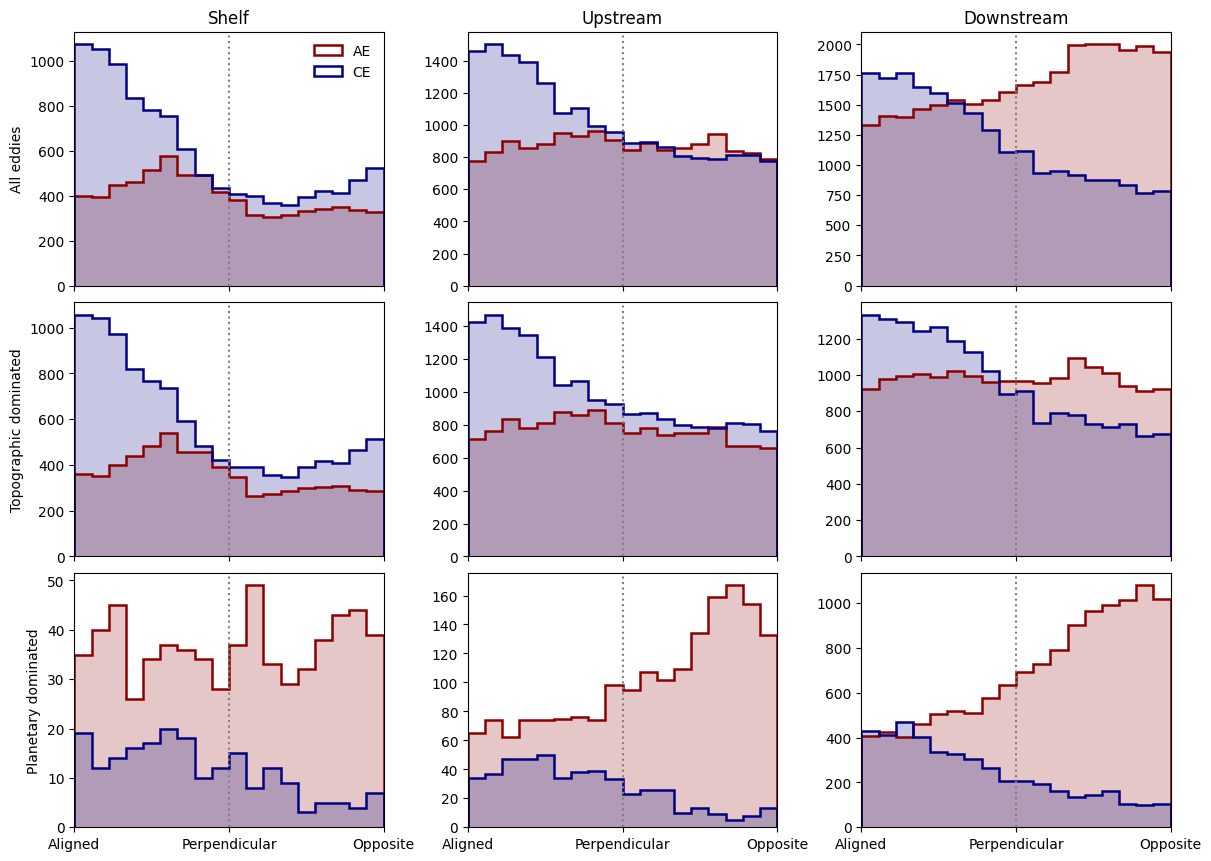

In [4]:
df_plot = df_eddies.copy() #df_eddies.loc[df_eddies.TiltDis > 20].copy()
row_filters = [
    ("All eddies", np.ones(len(df_plot), dtype=bool)),
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

fig, axs = plt.subplots(3, 3, figsize=(12, 8.5), sharex=True, constrained_layout=True)
for r, (row_label, mask) in enumerate(row_filters):
    row = df_plot.loc[mask]
    for c, regs in enumerate(region_groups):
        ax = axs[r, c]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            vals = row.loc[(row.Cyc == cyc) & (row.Region.isin(regs)), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if (r, c) == (0, 0) else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        if r == 0:
            ax.set_title(region_titles[c])
        if c == 0:
            ax.set_ylabel(row_label)
for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0, 0].legend(frameon=False)
plt.show()


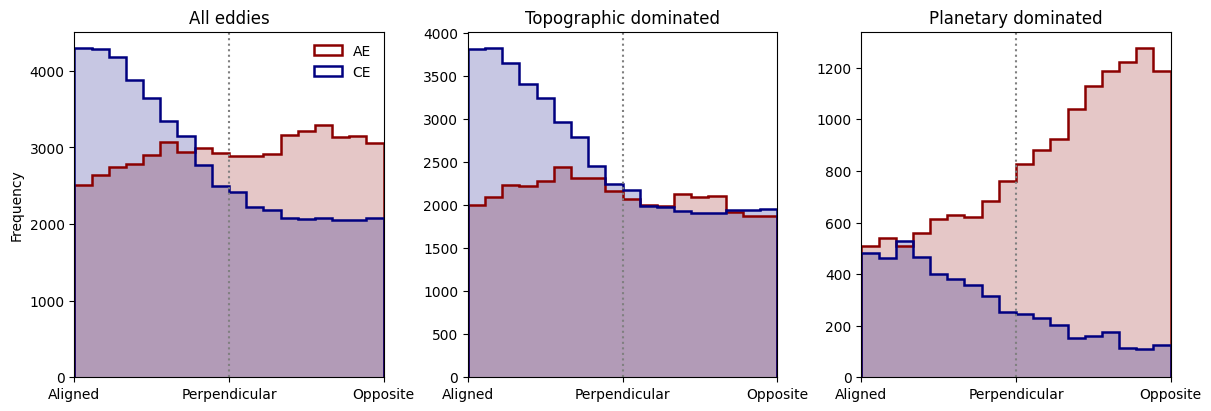

In [5]:
df_plot = df_eddies.copy()
# df_plot = df_plot[df_plot.TiltDis>5]
col_filters = [
    ("All eddies", np.ones(len(df_plot), dtype=bool)),
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, constrained_layout=True)
for c, (col_label, mask) in enumerate(col_filters):
        ax = axs[c]
        col = df_plot.loc[mask]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            vals = col.loc[(col.Cyc == cyc), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if c==0 else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        ax.set_title(col_label)
for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0].set_ylabel('Frequency')
axs[0].legend(frameon=False)
plt.show()

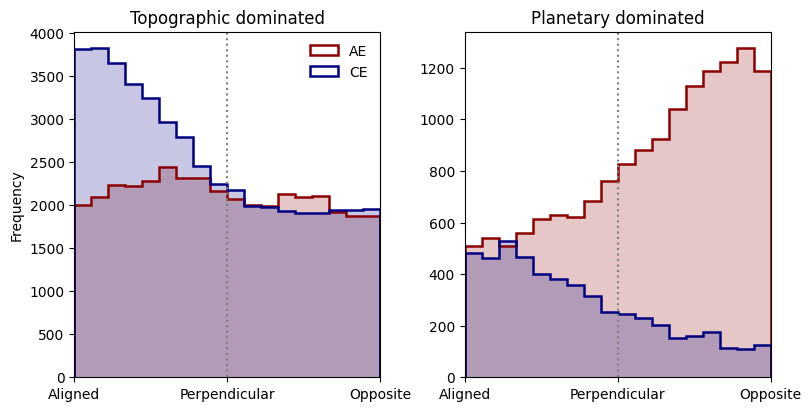

In [12]:
df_plot = df_eddies.copy()
# df_plot = df_plot[df_plot.TiltDis>5]
col_filters = [
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, constrained_layout=True)
for c, (col_label, mask) in enumerate(col_filters):
        ax = axs[c]
        col = df_plot.loc[mask]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            # if cyc=='CE':
            vals = col.loc[(col.Cyc == cyc), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if c==0 else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        ax.set_title(col_label)
for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0].set_ylabel('Frequency')
axs[0].legend(frameon=False)
plt.show()

## PV-gradient regional rose plot

The same regional rose layout can be used with PV-gradient magnitude and direction.


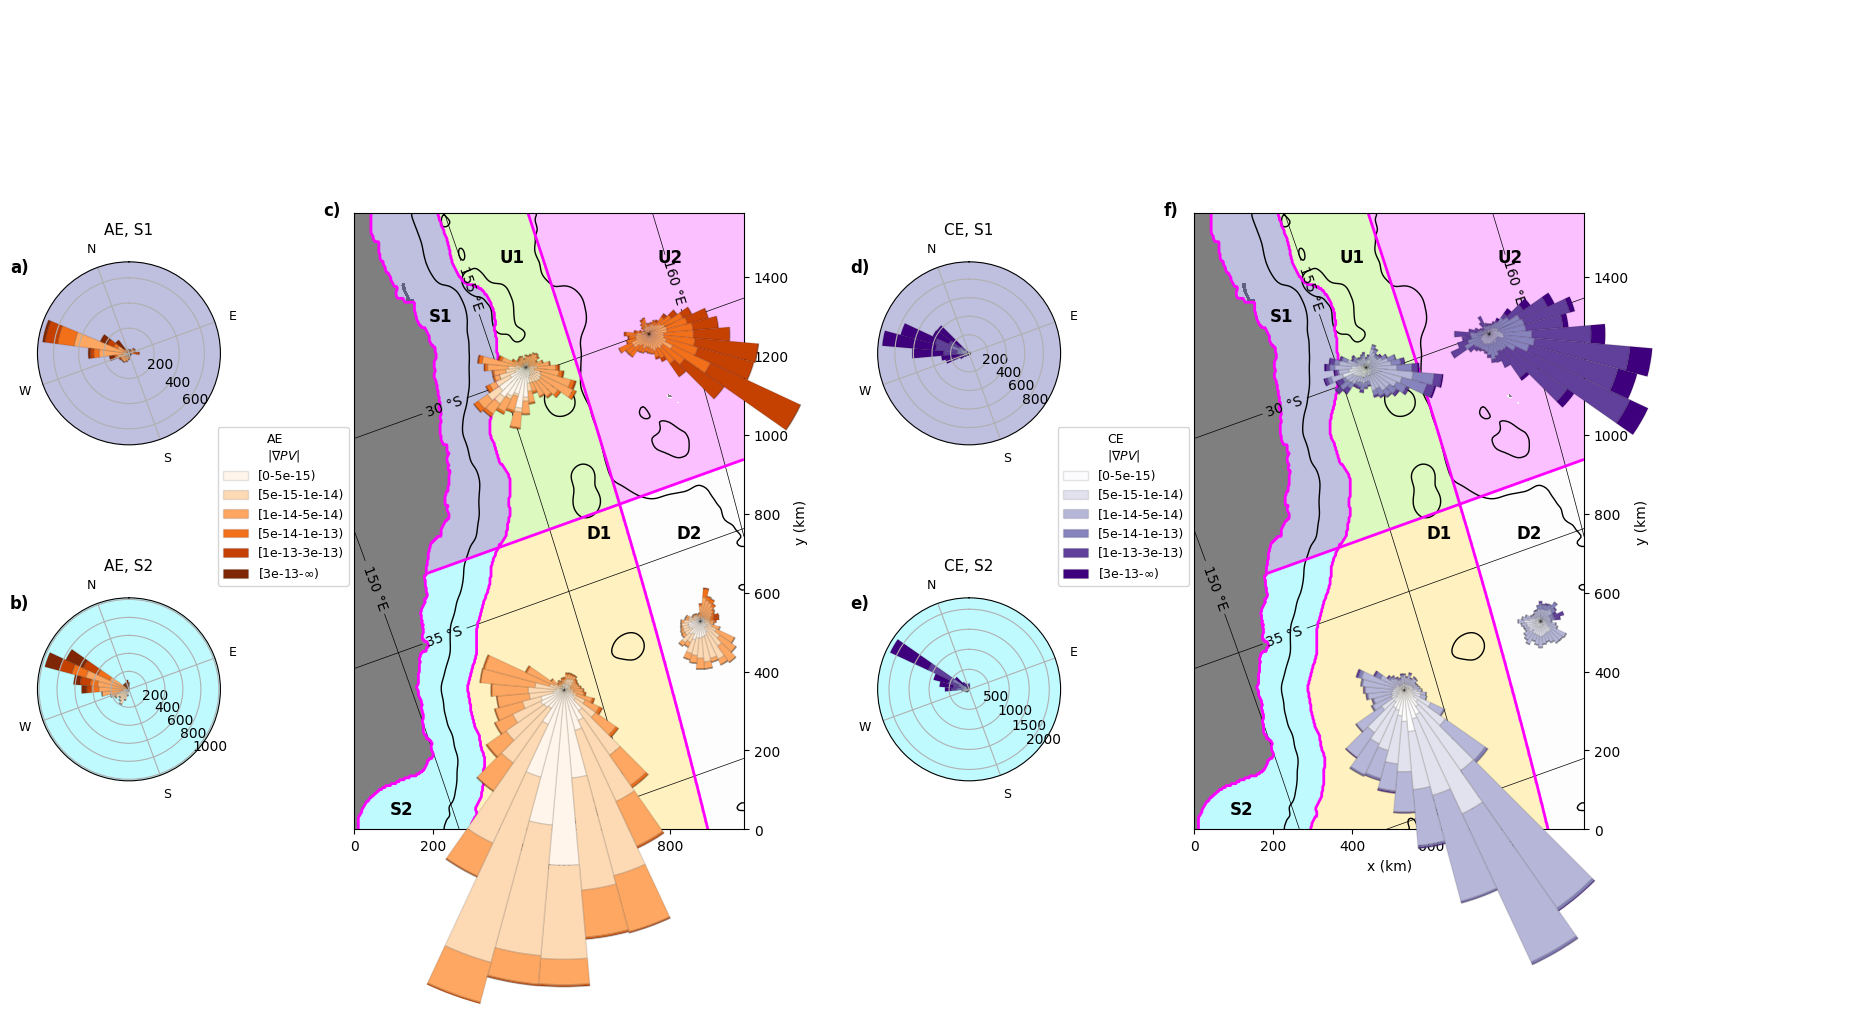

In [7]:
pv_mag_bins = [0, .5e-14, 1e-14, 5e-14, 1e-13, 3e-13, np.inf]
fig, rose = tilt.rose_plot(
    df_eddies.dropna(subset=["PV_grad_mag", "PV_grad_theta"]),
    grid,
    mag="PV_grad_mag",
    theta="PV_grad_theta",
    mag_bins=pv_mag_bins,
    frac=5,
    direction_offset=0,
    shelf_offset=80,
    legend_title=r"$|\nabla PV|$",
    rtick_flag=False,
    cmaps = ['Oranges', 'Purples']
)


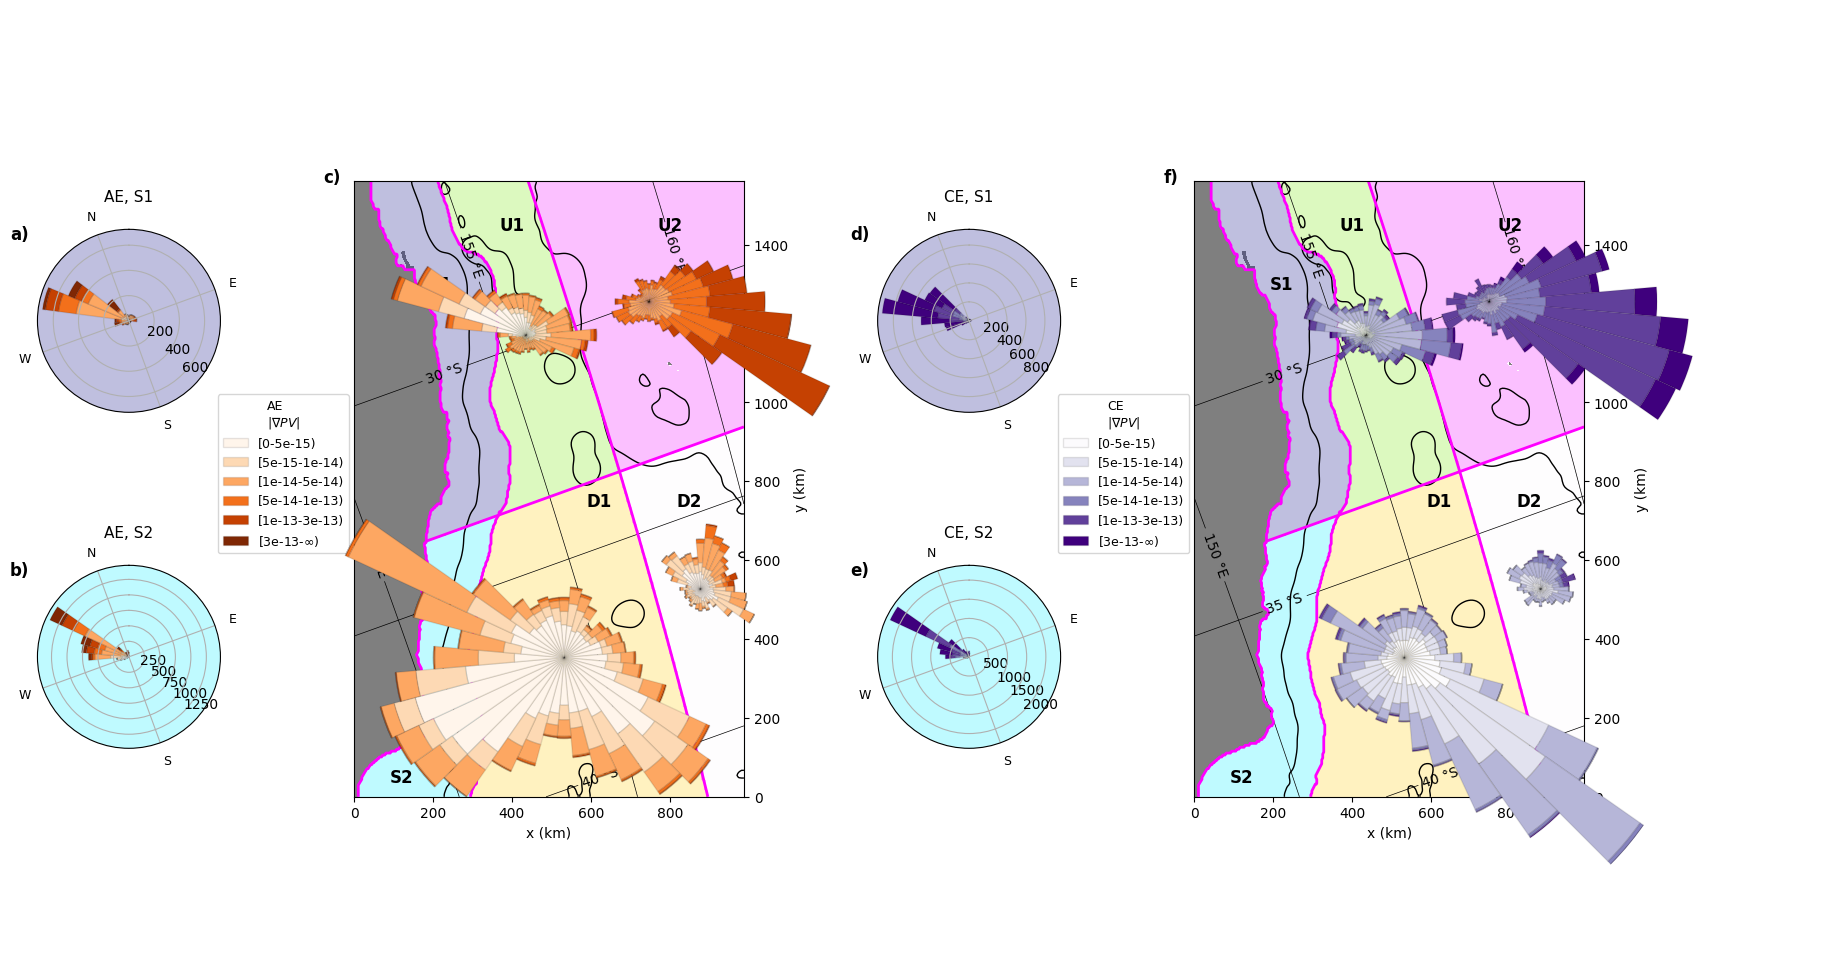

In [13]:
pv_mag_bins = [0, .5e-14, 1e-14, 5e-14, 1e-13, 3e-13, np.inf]
fig, rose = tilt.rose_plot(
    df_eddies.dropna(subset=["PV_grad_topo_mag", "PV_grad_topo_theta"]),
    grid,
    mag="PV_grad_topo_mag",
    theta="PV_grad_topo_theta",
    mag_bins=pv_mag_bins,
    frac=4.5,
    direction_offset=0,
    shelf_offset=80,
    legend_title=r"$|\nabla PV|$",
    rtick_flag=False,
    cmaps = ['Oranges', 'Purples']
)

#### PV dominance

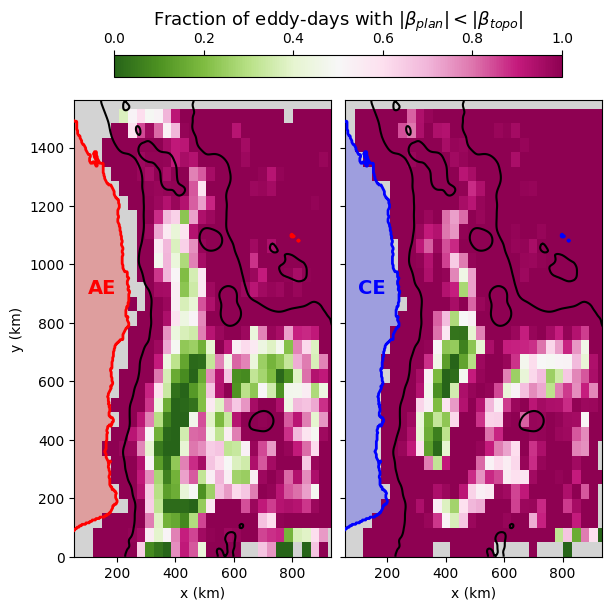

In [9]:
fig, axs = tilt.plot_pv_dominance(
    df_eddies.dropna(subset=["PV_grad_topo_mag", "PV_grad_plan_mag"]),
    grid,
    clabel=r'Fraction of eddy-days with $|\beta_{plan}| < |\beta_{topo}|$'
)
# region_mask_grid, bin_grid = tilt.make_region_grids(grid)
# for ax in axs:
#     ax.contour(grid.X_grid, grid.Y_grid, region_mask_grid.astype(float), levels=[0.5],
#                colors="magenta", linewidths=2, linestyles='-')

In [10]:
df_AE = df_eddies[df_eddies.Cyc == 'AE']
df_CE = df_eddies[df_eddies.Cyc == 'CE']

AE_PV = df_AE.PV_grad_mag.mean()
CE_PV = df_CE.PV_grad_mag.mean()

AE_topo = df_AE.PV_grad_topo_mag.mean()
CE_topo = df_CE.PV_grad_topo_mag.mean()

AE_plan = df_AE.PV_grad_plan_mag.mean()
CE_plan = df_CE.PV_grad_plan_mag.mean()

print('Mean PV-gradient magnitudes')
print('-' * 35)
print(f'Total:        AE = {AE_PV:.3e}    CE = {CE_PV:.3e}    (CE/AE = {CE_PV/AE_PV:.2f})')
print(f'Topographic:  AE = {AE_topo:.3e}    CE = {CE_topo:.3e}    (CE/AE = {CE_topo/AE_topo:.2f})')
print(f'Planetary:    AE = {AE_plan:.3e}    CE = {CE_plan:.3e}    (CE/AE = {CE_plan/AE_plan:.2f})')
print()
print('Topographic / Planetary ratio')
print('-' * 35)
print(f'AE = {AE_topo/AE_plan:.2f}')
print(f'CE = {CE_topo/CE_plan:.2f}')

Mean PV-gradient magnitudes
-----------------------------------
Total:        AE = 7.072e-14    CE = 4.251e-13    (CE/AE = 6.01)
Topographic:  AE = 6.991e-14    CE = 4.249e-13    (CE/AE = 6.08)
Planetary:    AE = 4.962e-15    CE = 5.821e-15    (CE/AE = 1.17)

Topographic / Planetary ratio
-----------------------------------
AE = 14.09
CE = 73.00
